In [10]:
# =====================================================
import numpy as np
import pandas as pd
import os
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    recall_score,
    precision_score,   
    make_scorer,
    silhouette_score,
    precision_recall_curve
)

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neighbors import NearestCentroid

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    AdaBoostClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import time

In [11]:
# 1. CARGAR DATOS
def cargar_y_preparar_datos(ruta_archivo):
    df = pd.read_excel(ruta_archivo)
    # Filtrar solo vivienda y copiar para evitar warnings
    df_viv = df[df['Proposito'].astype(str)
                .str.contains('Vivienda', case=False, na=False)].copy()
    # Label
    df_viv['Impago_Label'] = df_viv['Impago'].map({0:0, 1:1})
    return df_viv

# Ajusta esta ruta si es necesario
ruta_real = os.path.join('..', 'Datos', 'Limpios', 'información_préstamos_limpio.xlsx')

if os.path.exists(ruta_real):
    df = cargar_y_preparar_datos(ruta_real)
else:
    print(f" ATENCIÓN: No se encuentra el archivo en {ruta_real}")
    df = pd.DataFrame() 

In [12]:
# 2. DEFINIR X e y
if not df.empty:
    target_col = "Impago_Label"
    columnas_a_eliminar = ["ID", "Impago", "Prima", "Proposito"]

    y = df[target_col]
    X = df.drop(columns=[target_col])
    X = X.drop(columns=[col for col in columnas_a_eliminar if col in X.columns])

    # Eliminar alta cardinalidad
    high_card_cols = [col for col in X.columns if X[col].nunique() > 50]
    X = X.drop(columns=high_card_cols)

    # One-hot encoding
    cat_cols = X.select_dtypes(include="object").columns
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    X = X.astype("float32")
    
# 3. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

In [13]:
# 4. CLUSTERING: TORNEO K-MEANS vs AGLOMERATIVO
print("--- Iniciando Optimización de Clustering ---")

#1. Escalado
scaler_cluster = StandardScaler()
X_train_cluster = scaler_cluster.fit_transform(X_train)
X_test_cluster = scaler_cluster.transform(X_test)

# ENCONTRAR EL NÚMERO DE CLUSTERS (K) ÓPTIMO (Probamos de 2 a 5 clusters y nos quedamos con el mejor)

print(" Buscando el número óptimo de clusters (k)...")
best_k = 3  
best_k_score = -1

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_cluster)
    score = silhouette_score(X_train_cluster, labels)
    print(f"   k={k} -> Silhouette: {score:.4f}")
        
    if score > best_k_score:
        best_k_score = score
        best_k = k

print(f" Número óptimo seleccionado: k={best_k}")

#PASO 2: TORNEO CON EL K GANADOR (KMeans vs Aglomerativo)
print(f"\n--- Iniciando Torneo (usando k={best_k}) ---")

scores = {}
labels_storage = {}

# Función auxiliar
def asignar_clusters(model, X_train_scaled, X_test_scaled):
    labels_train = model.fit_predict(X_train_scaled)
    if hasattr(model, "predict"):
        labels_test = model.predict(X_test_scaled)
    else:
        centroid_clf = NearestCentroid()
        centroid_clf.fit(X_train_scaled, labels_train)
        labels_test = centroid_clf.predict(X_test_scaled)
        
    return labels_train, labels_test  
# Opción A: KMeans
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
k_labels_train, k_labels_test = asignar_clusters(kmeans, X_train_cluster, X_test_cluster)
scores["KMeans"] = silhouette_score(X_train_cluster, k_labels_train)
labels_storage["KMeans"] = (k_labels_train, k_labels_test)
print(f"Silhouette KMeans: {scores['KMeans']:.4f}")

# Opción B: Aglomerativo
agg = AgglomerativeClustering(n_clusters=best_k)
a_labels_train, a_labels_test = asignar_clusters(agg, X_train_cluster, X_test_cluster)
scores["Agglomerative"] = silhouette_score(X_train_cluster, a_labels_train)
labels_storage["Agglomerative"] = (a_labels_train, a_labels_test)
print(f"Silhouette Agglomerative: {scores['Agglomerative']:.4f}")

#SELECCIÓN FINAL
best_model_name = max(scores, key=scores.get)
print(f"GANADOR DEL TORNEO: {best_model_name} con k={best_k}")

# Aplicar al dataset
final_labels_train, final_labels_test = labels_storage[best_model_name]

# One-Hot Encoding
train_dummies = pd.get_dummies(final_labels_train, prefix='Cluster_Group')
test_dummies = pd.get_dummies(final_labels_test, prefix='Cluster_Group')

# Alinear columnas
test_dummies = test_dummies.reindex(columns=train_dummies.columns, fill_value=0)

# Unir
train_dummies.index = X_train.index
test_dummies.index = X_test.index
X_train = pd.concat([X_train, train_dummies], axis=1)
X_test = pd.concat([X_test, test_dummies], axis=1)

print(f" Variables de cluster añadidas. Nuevas columnas: {list(train_dummies.columns)}")

--- Iniciando Optimización de Clustering ---
 Buscando el número óptimo de clusters (k)...
   k=2 -> Silhouette: 0.1469
   k=3 -> Silhouette: 0.1327
   k=4 -> Silhouette: 0.1505
   k=5 -> Silhouette: 0.1456
 Número óptimo seleccionado: k=4

--- Iniciando Torneo (usando k=4) ---
Silhouette KMeans: 0.1505
Silhouette Agglomerative: 0.1801
GANADOR DEL TORNEO: Agglomerative con k=4
 Variables de cluster añadidas. Nuevas columnas: ['Cluster_Group_0', 'Cluster_Group_1', 'Cluster_Group_2', 'Cluster_Group_3']


In [14]:
# EXTRA: PERFILADO DE CLUSTERS (Que tipo de personas hay en cada cluster)
print("RADIOGRAFÍA DE LOS 4 CLUSTERS")

# 1. Juntamos los datos temporalmente para analizarlos
df_perfil = X_train.copy()
df_perfil['Impago_Real'] = y_train
df_perfil['Cluster_Asignado'] = final_labels_train  # Del 0 al 3

# 2. Vemos cuánta gente hay y cuántos morosos tiene cada cluster
resumen_clusters = df_perfil.groupby('Cluster_Asignado').agg(
    Total_Clientes=('Impago_Real', 'count'),
    Tasa_Morosidad_Pct=('Impago_Real', lambda x: (x.mean() * 100).round(2))
).reset_index()

print("MOROSIDAD POR CLUSTER:")
print(resumen_clusters.to_string(index=False))

# 3. Vemos cómo es el cliente medio de cada cluster
# Quitamos las columnas dummy de los propios clusters para no ensuciar
cols_a_ignorar = [c for c in df_perfil.columns if "Cluster_Group" in c]
df_perfil_limpio = df_perfil.drop(columns=cols_a_ignorar)

perfil_variables = df_perfil_limpio.groupby('Cluster_Asignado').mean().round(2).T

print("PERFIL MEDIO DEL CLIENTE EN CADA CLUSTER:")
# Mostramos todas las filas para que puedas ver todas las variables
pd.set_option('display.max_rows', None) 
print(perfil_variables)

RADIOGRAFÍA DE LOS 4 CLUSTERS
MOROSIDAD POR CLUSTER:
 Cluster_Asignado  Total_Clientes  Tasa_Morosidad_Pct
                0            3853               11.06
                1            3071               14.00
                2             443                9.03
                3             826                4.96
PERFIL MEDIO DEL CLIENTE EN CADA CLUSTER:
Cluster_Asignado                               0          1          2  \
Num_Creditos                            2.210000   2.200000   2.010000   
Duracion                               32.549999  33.279999  33.099998   
Ratio_Deuda_Ingresos                    0.510000   0.490000   0.450000   
Posesion_Hipoteca                       0.420000   0.430000   0.420000   
Personas_Cargo                          0.460000   0.460000   0.380000   
Fiador                                  0.510000   0.500000   0.490000   
Estudios_Escolar                        0.990000   0.000000   0.000000   
Estudios_Grado Universitario            0.0

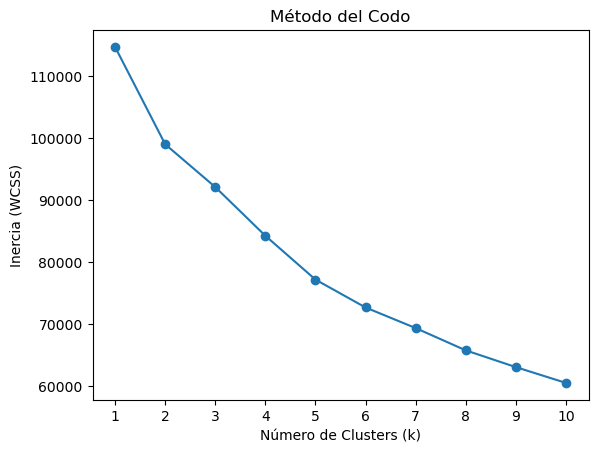

In [20]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inercia = []
valores_k = range(1, 11)

for k in valores_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_train_cluster)
    inercia.append(km.inertia_)

plt.figure()
plt.plot(valores_k, inercia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia (WCSS)")
plt.xticks(valores_k)
plt.show()

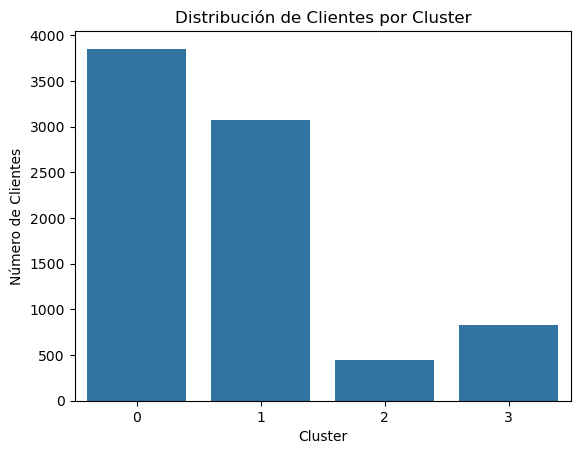

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.countplot(x=final_labels_train)
plt.title("Distribución de Clientes por Cluster")
plt.xlabel("Cluster")
plt.ylabel("Número de Clientes")
plt.show()

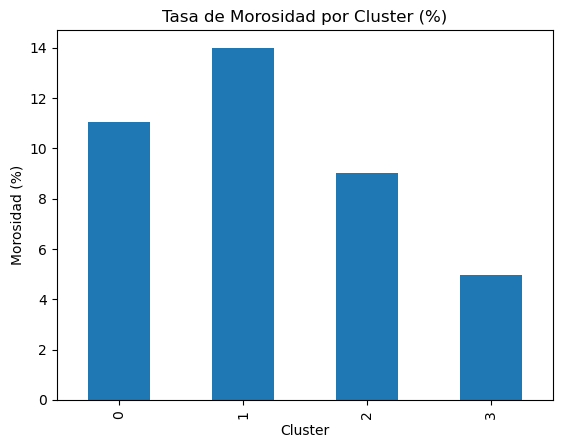

In [16]:
morosidad_cluster = df_perfil.groupby('Cluster_Asignado')['Impago_Real'].mean() * 100

plt.figure()
morosidad_cluster.plot(kind='bar')
plt.title("Tasa de Morosidad por Cluster (%)")
plt.ylabel("Morosidad (%)")
plt.xlabel("Cluster")
plt.show()

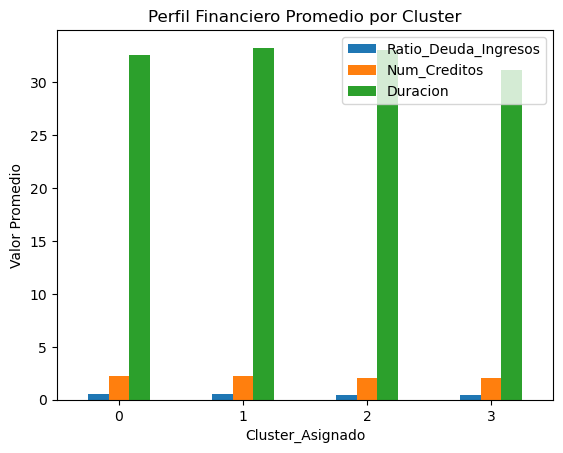

In [17]:
variables_clave = [
    "Ratio_Deuda_Ingresos",
    "Num_Creditos",
    "Duracion"
]

perfil_financiero = df_perfil_limpio.groupby("Cluster_Asignado")[variables_clave].mean()

perfil_financiero.plot(kind='bar')
plt.title("Perfil Financiero Promedio por Cluster")
plt.ylabel("Valor Promedio")
plt.xticks(rotation=0)
plt.show()

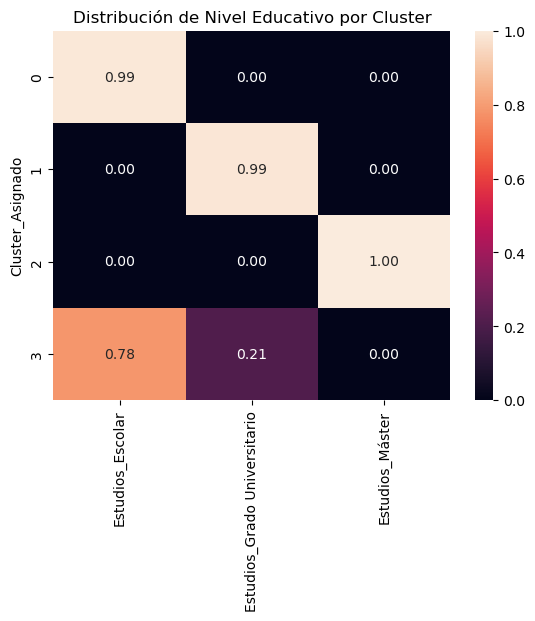

In [18]:
cols_estudios = [col for col in df_perfil.columns if "Estudios_" in col]

tabla_estudios = df_perfil.groupby("Cluster_Asignado")[cols_estudios].mean()

plt.figure()
sns.heatmap(tabla_estudios, annot=True, fmt=".2f")
plt.title("Distribución de Nivel Educativo por Cluster")
plt.show()